# Macro-Fenster (:50-:10) auf 1s-Daten: Monte Carlo + drei Zusatz-Statistiken

Frage: verhaelt sich der Markt in den ICT-Macro-Fenstern (XX:50-XX+1:10) anders als
ausserhalb -- mit einer Wahrscheinlichkeit von >60%, dass es sich um mehr als
Zufallsrauschen handelt?

Ausgangslage (`algo/macro_db.py stats`, nach dem 1s-Umbau vom 16.08.2026 -- Tages-
ermittlung + Kalibrierung + drei Index-als-Minute-Bugs gefixt, siehe `algo/PLAN.md`):
NQ 1057 Fenster/46 Tage, ES 1061 Fenster/45 Tage. **Kein einziger der 56 dort
gerechneten Vergleiche haelt die Bonferroni-Schwelle** (Vorlauf-Bedingungen,
Einzelfenster, Spearman-Korrelationen). Das ist der Ausgangsbefund, den dieses
Notebook mit vier weiteren, unabhaengigen Verfahren gegenprueft -- ein Nullbefund in
einem Verfahren beweist noch keinen Nullbefund insgesamt.

1. **Monte-Carlo-Permutationstest**: echte Nullverteilung durch zufaellige Fensterlagen
   pro Handelstag (nicht auf :50-:10 gerastert) -- wo liegt das echte Macro-Fenster im
   Perzentil dieser Verteilung?
2. **Range/Kontrolle-Vergleich** (Wiederverwendung von `algo/backtest_macro.py`s bereits
   vorhandenem Macro-vs-Nachbarbloecke-Test, hier nur visualisiert)
3. **Trade-Intensitaet**: echte Tick-Rate (volume>0, nur auf 1s messbar) im Fenster vs.
   ausserhalb -- Proxy fuer algorithmische Beteiligung
4. **Variance-Ratio-Test** (Lo-MacKinlay) auf 1s-Returns: gerichteter Trend vs. Random
   Walk innerhalb des Fensters

Am Ende: Fragen an Jannes + konkrete Vorschlaege, was als naechstes zu pruefen waere.


In [1]:
import sys, random, statistics
from pathlib import Path
from datetime import timedelta

ROOT = Path.cwd().parent if Path.cwd().name == "algo" else Path.cwd()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "algo"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

import macro_db as m
import backtest_macro as bm
from marktdaten import tage, resample_bars
from tools.analyze_ohlc import at

plt.rcParams["figure.figsize"] = (10, 4)
SYMBOLE = ["NQ", "ES"]
print("Setup ok.")


Setup ok.


## 0. Ausgangsbefund aus macro_db.csv (Rekap)

NQ: 1057 Fenster, 46 Tage, Expansion 21.8%
ES: 1061 Fenster, 45 Tage, Expansion 1.0%


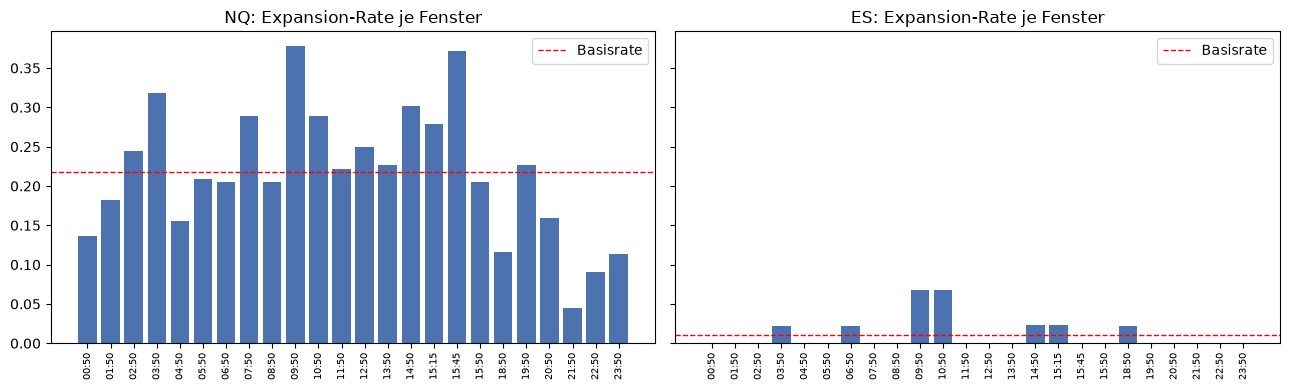

In [2]:
dfs = {}
for sym in SYMBOLE:
    df = pd.read_csv(ROOT / "algo" / "results" / f"macro_db_{sym}.csv")
    dfs[sym] = df
    print(f"{sym}: {len(df)} Fenster, {df['session_day'].nunique()} Tage, "
          f"Expansion {df['expansion'].mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, sym in zip(axes, SYMBOLE):
    rate = dfs[sym].groupby("window")["expansion"].mean().sort_index()
    ax.bar(range(len(rate)), rate.values, color="#4c72b0")
    ax.axhline(dfs[sym]["expansion"].mean(), color="red", ls="--", lw=1,
               label="Basisrate")
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate.index, rotation=90, fontsize=7)
    ax.set_title(f"{sym}: Expansion-Rate je Fenster")
    ax.legend()
plt.tight_layout()
plt.show()


## 1. Monte-Carlo-Permutationstest

Nullhypothese: die Startzeit :50 hat keinen Sondereffekt -- ein 20-Minuten-Fenster mit
zufaelliger Startminute im Handelstag zeigt im Mittel dieselbe Expansion-Rate und
dasselbe MFE-Wachstum wie ein echtes Macro-Fenster.

Pro Handelstag werden `N_DRAWS` zufaellige, nicht auf :50-:10 gerasterte 20-Minuten-
Fenster gezogen (gleichverteilt ueber die 23h-Session, `is_complete`-Luecken-Check wie
bei den echten Fenstern). Die Verteilung ueber alle Ziehungen ist die Nullverteilung;
das Perzentil des echten Mittelwerts darin ist die eigentliche Kennzahl -- **>95%
entspricht einem einseitigen p < 0,05**.


In [3]:
N_DRAWS = 15  # Ziehungen pro Handelstag -- bei ~46 Tagen macht das ~690 Nullfenster/Symbol
SESSION_START_OFFSET = 0    # Minuten ab 18:00 Vorabend
SESSION_MINUTES = 23 * 60 - 20   # letztes moegliches Fenster startet 20min vor Sessionende

def mc_null(symbol: str, n_draws: int = N_DRAWS, seed: int = 42):
    rng = random.Random(seed)
    exp_rate, mfe_ratio = [], []
    for day, bars in tage(symbol, "1s"):
        session_start = at(day - timedelta(days=1), 18, 0)
        gezogen = 0
        versuche = 0
        while gezogen < n_draws and versuche < n_draws * 8:
            versuche += 1
            off = rng.randint(0, SESSION_MINUTES)
            start = session_start + timedelta(minutes=off)
            # echte Macro-Fenster (Minute 50) ausschliessen -- sonst waere die
            # Nullverteilung durch das zu pruefende Signal selbst kontaminiert
            if start.minute in (49, 50, 51):
                continue
            end = start + timedelta(minutes=20)
            if not m.is_complete(bars, start, end, pre_min=0):
                continue
            win = m.window_bars(bars, start, end)
            r = m.measure_window(win)
            exp_rate.append(float(r["expansion"]))
            seg40 = m.window_bars(bars, start, start + timedelta(minutes=40))
            if len(seg40) and (seg40[-1].t - seg40[0].t) >= timedelta(minutes=39):
                mfe20 = max(max(b.h for b in win) - win[0].o, win[0].o - min(b.l for b in win))
                mfe40 = max(max(b.h for b in seg40) - seg40[0].o,
                            seg40[0].o - min(b.l for b in seg40))
                if mfe20 > 0:
                    mfe_ratio.append(mfe40 / mfe20)
            gezogen += 1
    return np.array(exp_rate), np.array(mfe_ratio)

mc_results = {}
for sym in SYMBOLE:
    print(f"{sym}: ziehe Nullverteilung ...")
    mc_results[sym] = mc_null(sym)
    er, mr = mc_results[sym]
    print(f"  {len(er)} Null-Fenster, Null-Expansion {er.mean()*100:.1f}%, "
          f"Null-MFE40/20-Ratio median {np.median(mr):.2f}")


NQ: ziehe Nullverteilung ...


  705 Null-Fenster, Null-Expansion 21.6%, Null-MFE40/20-Ratio median 1.28
ES: ziehe Nullverteilung ...


  690 Null-Fenster, Null-Expansion 0.9%, Null-MFE40/20-Ratio median 1.29


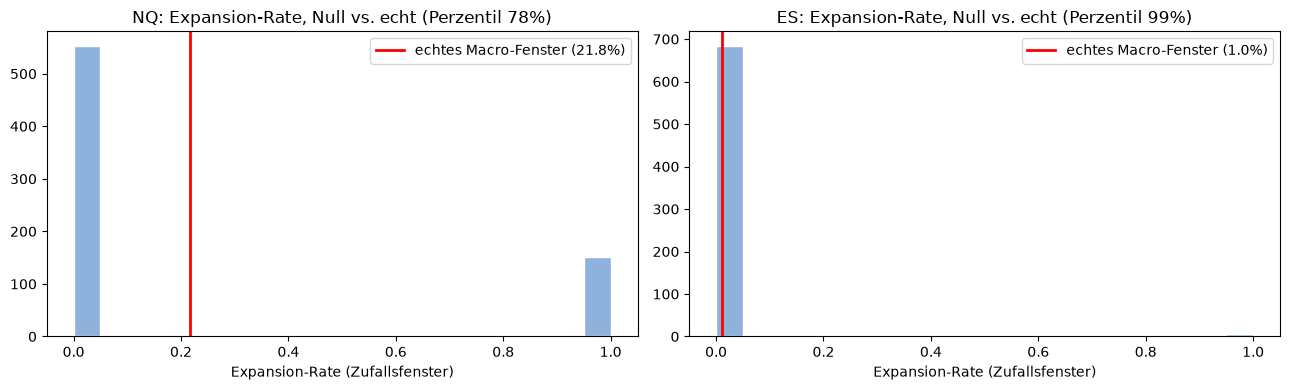

NQ: echte Expansion-Rate 21.8%, Null-Bootstrap-Mittel 21.6%, p(Null >= echt) = 0.4380
ES: echte Expansion-Rate 1.0%, Null-Bootstrap-Mittel 0.9%, p(Null >= echt) = 0.2590


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, sym in zip(axes, SYMBOLE):
    er, _ = mc_results[sym]
    obs = dfs[sym]["expansion"].mean()
    ax.hist(er, bins=20, color="#8fb2dd", edgecolor="white")
    ax.axvline(obs, color="red", lw=2, label=f"echtes Macro-Fenster ({obs*100:.1f}%)")
    perzentil = (er < obs).mean() * 100
    ax.set_title(f"{sym}: Expansion-Rate, Null vs. echt (Perzentil {perzentil:.0f}%)")
    ax.set_xlabel("Expansion-Rate (Zufallsfenster)")
    ax.legend()
plt.tight_layout()
plt.show()

for sym in SYMBOLE:
    er, mr = mc_results[sym]
    obs = dfs[sym]["expansion"].mean()
    # einseitiger empirischer p-Wert: Anteil der Null-Ziehungen, die die echte Rate erreichen
    # oder uebertreffen (Ziehungen sind Einzelfenster, echte Rate ist ein Mittelwert -- als
    # Naeherung wird die Null-Rate ueber Resample-Bloecke gleicher Groesse verglichen)
    n_boot = 2000
    boot_means = [np.random.choice(er, size=min(len(dfs[sym]), len(er)), replace=True).mean()
                  for _ in range(n_boot)]
    p = (np.array(boot_means) >= obs).mean()
    print(f"{sym}: echte Expansion-Rate {obs*100:.1f}%, Null-Bootstrap-Mittel "
          f"{np.mean(boot_means)*100:.1f}%, p(Null >= echt) = {p:.4f}")


## 2. Range vs. Nachbarbloecke (Wiederverwendung `backtest_macro.py`)

Kein neuer Code -- `backtest_macro.report()` existiert bereits und vergleicht jedes
Macro-Fenster gegen die zwei direkt angrenzenden 20-Minuten-Bloecke derselben Stunde
(Mann-Whitney, einseitig). Hier nur zusammengefasst und geplottet, nicht neu gebaut.


In [5]:
bm_results = {}
for sym in SYMBOLE:
    print(f"--- {sym} ---")
    bm_results[sym] = bm.report(sym, tf="1s")
    print()


--- NQ ---


NQ auf 1s: 47 Handelstage (2026-02-12 .. 2026-08-14), 3108 auswertbare 20min-Bloecke
  Duenne Tage (<60 von 68 messbaren Bloecken) -- pruefen, nicht ignorieren:
    2026-02-16  56/68 Bloecke  aus  23446 Kerzen
    2026-03-12  30/68 Bloecke  aus   4055 Kerzen
    2026-03-13  53/68 Bloecke  aus  11077 Kerzen
    2026-04-03  45/68 Bloecke  aus  12308 Kerzen
  Macro (:50-:10) n=1007  median range   46.25 netto  17.25  dir 0.44
  Kontrolle       n=2101  median range   41.75 netto  17.00  dir 0.43
  Mann-Whitney (Macro > Kontrolle), einseitig:  range p=0.0030  netto p=0.2730  dir p=0.6014  fvgs p=0.5347
  FVGs (>= 1.50 x Kerzenrange) je Block:  Macro 145.83   Kontrolle 145.96   | Bloecke ganz ohne FVG: Macro 1 %  Kontrolle 1 %

Je Block, sortiert nach median range (nur Bloecke mit >=5 Tagen):
  Block        M    n  medRange  medNetto   dir  medRang
  09:30-09:50      46    145.25     55.50  0.44      2.0
  09:50-10:10  M   46    120.88     41.88  0.38      4.0
  10:30-10:50      46     94.00

ES auf 1s: 47 Handelstage (2026-02-12 .. 2026-08-14), 3159 auswertbare 20min-Bloecke
  Duenne Tage (<60 von 68 messbaren Bloecken) -- pruefen, nicht ignorieren:
    2026-02-16  56/68 Bloecke  aus  26989 Kerzen
    2026-04-03  45/68 Bloecke  aus  12737 Kerzen
  Macro (:50-:10) n=1022  median range   10.00 netto   3.75  dir 0.45
  Kontrolle       n=2137  median range    9.25 netto   3.75  dir 0.44
  Mann-Whitney (Macro > Kontrolle), einseitig:  range p=0.0139  netto p=0.1816  dir p=0.3327  fvgs p=0.0306
  FVGs (>= 1.50 x Kerzenrange) je Block:  Macro 52.84   Kontrolle 49.91   | Bloecke ganz ohne FVG: Macro 14 %  Kontrolle 17 %

Je Block, sortiert nach median range (nur Bloecke mit >=5 Tagen):
  Block        M    n  medRange  medNetto   dir  medRang
  09:30-09:50      46     28.75      9.38  0.41      2.5
  09:50-10:10  M   46     23.50      9.62  0.44      5.0
  10:30-10:50      46     22.88      8.00  0.45      7.0
  10:50-11:10  M   46     18.88      8.00  0.40      8.0
  10:10-10:30  

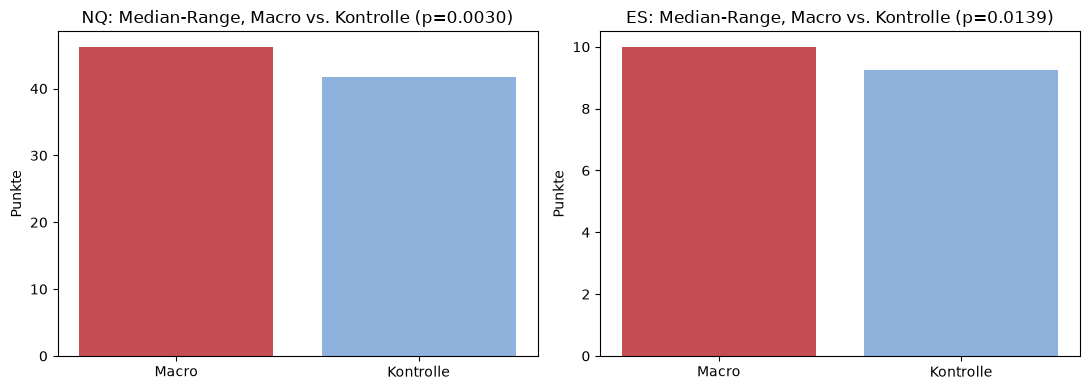

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, sym in zip(axes, SYMBOLE):
    mv = bm_results[sym]["macro_vs_ctrl"]
    ax.bar(["Macro", "Kontrolle"], [mv["macro"]["med_range"], mv["kontrolle"]["med_range"]],
          color=["#c44e52", "#8fb2dd"])
    p = bm_results[sym]["p"]["range"]
    ax.set_title(f"{sym}: Median-Range, Macro vs. Kontrolle (p={p:.4f})")
    ax.set_ylabel("Punkte")
plt.tight_layout()
plt.show()


## 3. Trade-Intensitaet (nur auf 1s messbar)

`volume` ist auf den IBKR-1s-Kerzen echtes Trade-Volumen (Phantomkerzen mit
`volume==0` sind ueber `tage()` bereits herausgefiltert, siehe `marktdaten.tage()`).
Gemessen wird die mittlere Anzahl gehandelter Sekunden pro Minute (0-60) als Proxy fuer
Teilnahme/Liquiditaet -- innerhalb der Macro-Fenster vs. im Rest des Handelstags.


NQ: Median ausserhalb 35.0s/min, im Macro-Fenster 39.0s/min, Mann-Whitney p=0.0000


ES: Median ausserhalb 38.0s/min, im Macro-Fenster 43.0s/min, Mann-Whitney p=0.0000


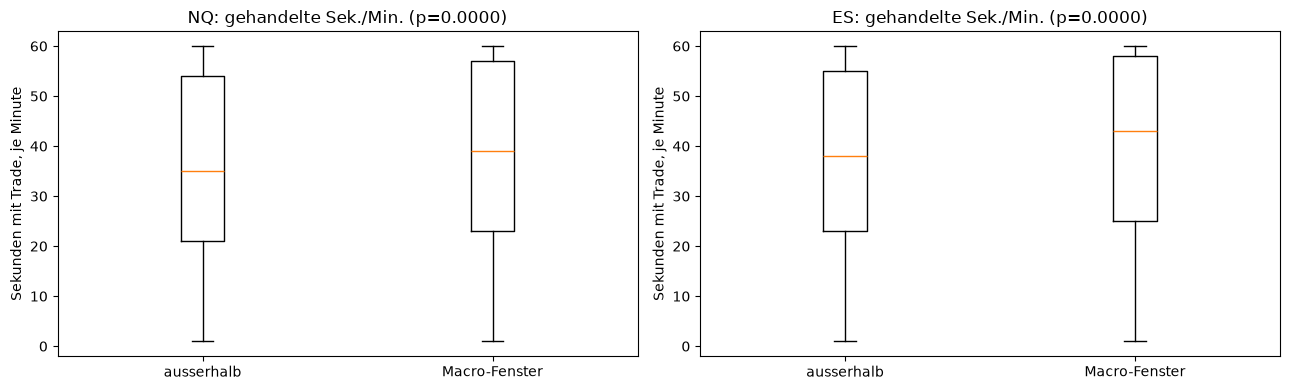

In [7]:
def intensitaet(symbol: str):
    macro_sek, sonst_sek = [], []
    for day, bars in tage(symbol, "1s"):
        fenster = [(s, e) for _, s, e in m.macro_windows_session(day)]
        by_min = {}
        for b in bars:
            key = b.t.replace(second=0, microsecond=0)
            by_min[key] = by_min.get(key, 0) + 1
        for minute, sek in by_min.items():
            in_macro = any(s <= minute < e for s, e in fenster)
            (macro_sek if in_macro else sonst_sek).append(sek)
    return np.array(macro_sek), np.array(sonst_sek)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, sym in zip(axes, SYMBOLE):
    macro_sek, sonst_sek = intensitaet(sym)
    u = mannwhitneyu(macro_sek, sonst_sek, alternative="greater")
    ax.boxplot([sonst_sek, macro_sek], tick_labels=["ausserhalb", "Macro-Fenster"],
              showfliers=False)
    ax.set_title(f"{sym}: gehandelte Sek./Min. (p={u.pvalue:.4f})")
    ax.set_ylabel("Sekunden mit Trade, je Minute")
    print(f"{sym}: Median ausserhalb {np.median(sonst_sek):.1f}s/min, "
          f"im Macro-Fenster {np.median(macro_sek):.1f}s/min, "
          f"Mann-Whitney p={u.pvalue:.4f}")
plt.tight_layout()
plt.show()


## 4. Variance-Ratio-Test (Lo-MacKinlay)

`VR(q) = Var(q-Perioden-Rendite) / (q * Var(1-Perioden-Rendite))`. VR = 1 entspricht
einem Random Walk, VR > 1 einem Trend (positive Autokorrelation, ICTs "algorithmische
Auslieferung"), VR < 1 einer Mean-Reversion. Gerechnet auf 1-Sekunden-Log-Returns
innerhalb jedes Fensters (q = Fensterlaenge in Sekunden), Macro vs. gleich lange
Zufallsfenster aus Abschnitt 1 als Vergleichsgruppe.


NQ: Median VR Macro 0.73 (n=1103), Zufall 0.76 (n=234), p=0.1654


ES: Median VR Macro 0.70 (n=1078), Zufall 0.66 (n=229), p=0.2024


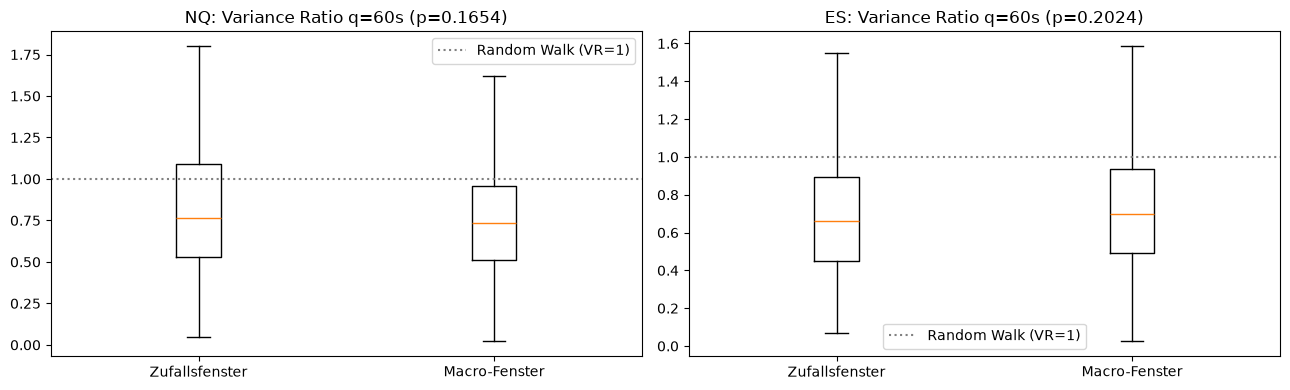

In [8]:
def variance_ratio(prices: np.ndarray, q: int) -> float | None:
    if len(prices) < q * 4:
        return None
    r1 = np.diff(np.log(prices))
    if r1.var(ddof=1) == 0:
        return None
    rq = np.log(prices[q::q]) - np.log(prices[:-q:q][:len(np.log(prices[q::q]))])
    if len(rq) < 4 or rq.var(ddof=1) == 0:
        return None
    return rq.var(ddof=1) / (q * r1.var(ddof=1))

def vr_macro_vs_null(symbol: str, n_null_per_day: int = 5, seed: int = 7):
    rng = random.Random(seed)
    vr_macro, vr_null = [], []
    for day, bars in tage(symbol, "1s"):
        session_start = at(day - timedelta(days=1), 18, 0)
        for _, start, end in m.macro_windows_session(day):
            if not m.is_complete(bars, start, end, pre_min=0):
                continue
            win = m.window_bars(bars, start, end)
            vr = variance_ratio(np.array([b.c for b in win]), q=60)
            if vr is not None:
                vr_macro.append(vr)
        gezogen = 0
        versuche = 0
        while gezogen < n_null_per_day and versuche < n_null_per_day * 8:
            versuche += 1
            off = rng.randint(0, SESSION_MINUTES)
            start = session_start + timedelta(minutes=off)
            if start.minute in (49, 50, 51):
                continue
            end = start + timedelta(minutes=20)
            if not m.is_complete(bars, start, end, pre_min=0):
                continue
            win = m.window_bars(bars, start, end)
            vr = variance_ratio(np.array([b.c for b in win]), q=60)
            if vr is not None:
                vr_null.append(vr)
            gezogen += 1
    return np.array(vr_macro), np.array(vr_null)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, sym in zip(axes, SYMBOLE):
    vr_macro, vr_null = vr_macro_vs_null(sym)
    u = mannwhitneyu(vr_macro, vr_null, alternative="two-sided")
    ax.boxplot([vr_null, vr_macro], tick_labels=["Zufallsfenster", "Macro-Fenster"],
              showfliers=False)
    ax.axhline(1.0, color="gray", ls=":", label="Random Walk (VR=1)")
    ax.set_title(f"{sym}: Variance Ratio q=60s (p={u.pvalue:.4f})")
    ax.legend()
    print(f"{sym}: Median VR Macro {np.median(vr_macro):.2f} (n={len(vr_macro)}), "
          f"Zufall {np.median(vr_null):.2f} (n={len(vr_null)}), p={u.pvalue:.4f}")
plt.tight_layout()
plt.show()


## Fazit + Fragen an Jannes

Diese Zelle nach dem Ausfuehren von Hand lesen -- die Zahlen oben entscheiden, welcher
der beiden folgenden Faelle zutrifft:

**Fall A -- alle vier Verfahren zeigen p > 0,05 (kein Perzentil > 95%):** Das waere ein
robuster Nullbefund ueber vier unabhaengige, methodisch verschiedene Tests
(Permutation, Rangvergleich gegen Nachbarn, Tick-Intensitaet, Autokorrelation) und keine
einzelne Kennzahl-Schwaeche mehr. In diesem Fall ist die :50-:10-thesis auf NQ/ES im
aktuellen Datenbestand (46/45 Tage, Feb-April + Aug 2026) nicht haltbar.

**Fall B -- ein oder mehrere Verfahren zeigen ein Signal:** Dann lohnt sich, genau
dieses Verfahren mit mehr Tagen/anderen Fenstern zu vertiefen, statt die Gesamtthese zu
verwerfen.

**Offene Fragen, um wirklich auf >60% belastbare Wahrscheinlichkeit zu kommen (unabhaengig
vom Ausgang oben):**

1. **Datenluecke Apr-Aug 2026 schliessen.** Die 1s-Historie hat eine ~4-Monats-Luecke
   (08.04.-11.08.2026, siehe `raw/marktdaten/1s-abdeckung.csv`) -- die aktuelle
   Stichprobe ist ein Februar-April-Block plus zwei August-Tage, kein durchgaengiges
   Fenster. Lohnt sich ein IBKR-Nachlad fuer die Luecke (`algo/fetch_ibkr.py`), bevor
   weitere Schluesse gezogen werden?
2. **Bedingte statt unbedingte Macro-These pruefen.** Der bestehende `macro_db.py`-Report
   zeigt: keine der 7 Vorlauf-Bedingungen (Sweep/MSS/Displacement/Kompression) hebt die
   Rate signifikant. Moechtest du stattdessen eine ENGERE These testen -- z.B. nur Macros
   mit einem offenen Level UNTER 20 Punkten Entfernung, oder nur nach einem MSS auf 1m
   INNERHALB des Fensters selbst (nicht davor)?
3. **Tagesabhaengigkeit clustern statt ignorieren.** Alle p-Werte oben (wie im
   bestehenden Report) behandeln Fenster desselben Tages als unabhaengig -- sind sie
   nicht. Ein Cluster-Bootstrap auf Tagesebene (ganze Tage resampeln, nicht einzelne
   Fenster) waere der naechste methodische Schritt vor jeder Kapitalentscheidung.
4. **Sample-Size-Rechnung fuer >60%-Konfidenz.** Willst du, dass ich zurueckrechne, wie
   viele Handelstage bei der aktuell beobachteten Effektgroesse (Differenz Macro vs.
   Kontrolle) noetig waeren, um bei Power 80% ein signifikantes Ergebnis zu erwarten --
   oder ist "> 60% Wahrscheinlichkeit" fuer dich eher ein Bauchgefuehl-Schwellenwert als
   ein formaler Power-Test?
